<a href="https://colab.research.google.com/github/ggalanc/proyecto_dengue/blob/main/notebooks/practico_06_proyecto_final_fase4_drift_Gerardo_Galan_Mabel_Herrera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Práctico Final: MLOps Local con Monitoreo de Data Drift
## Fase 4 — Monitoreo de Drift
### Magíster en Ciencia de Datos — Tópicos en Data Science II
---

**Integrantes:** Gerardo Galán - Mabel Herrera

**Continúa de:** Fase 2 (modelo entrenado, `models/modelo_dengue.joblib`) y Fase 3 (servicio de inferencia, `service/`).

---

## Objetivo de esta fase (RAA4)

1. **Alimentar el servicio de inferencia** con `data/processed/produccion_simulada.csv` — el 20% más reciente de cada ciudad, reservado en la Fase 2, con etiquetas verdaderas, nunca visto en entrenamiento — dividido en **4 ventanas temporales** por ciudad.
2. Calcular **métricas de drift propias** (PSI y KS-test) por variable y por ventana, comparadas contra la distribución de referencia (Fase 2).
3. Calcular la **degradación de desempeño** (MAE) por ventana, usando el log de predicciones del servicio.
4. **Justificar el umbral** de alerta elegido (incluyendo una decisión de diseño que no suele discutirse: cuántos bins usar en el PSI cuando las ventanas son chicas).
5. Dejar todo integrado para el **dashboard de Streamlit** (`dashboard/dashboard.py`).


---
## 🔧 Bootstrap para Google Colab

Esta celda trae el proyecto completo (código en `src/`, `service/`, datos y modelo ya entrenado) al entorno de Colab, que empieza vacío en cada sesión. Si `REPO_URL` está vacío, la celda ofrece subir un `.zip` del repositorio en su lugar.

**No hace falta editar nada más de este notebook** — el resto de las celdas ya usan rutas relativas (`../data/`, `../models/`, etc.) que funcionan igual aquí que en una máquina local, una vez que el directorio de trabajo queda en `notebooks/`.


In [ ]:
# ── Bootstrap para Google Colab: trae el repositorio a este entorno ──
import os

REPO_URL = "https://github.com/ggalanc/proyecto_dengue.git"
REPO_DIR = "/content/dengue_mlops_drift_repo_1"

IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ

if IN_COLAB and not os.path.exists(REPO_DIR):
    if REPO_URL:
        print("Clonando repositorio...")
        get_ipython().system('git clone -q "{}" "{}"'.format(REPO_URL, REPO_DIR))
    else:
        print("REPO_URL esta vacio. Selecciona el .zip del repositorio para subirlo:")
        from google.colab import files
        subido = files.upload()
        zip_name = list(subido.keys())[0]
        os.makedirs(REPO_DIR, exist_ok=True)
        get_ipython().system('unzip -q "{}" -d "{}"'.format(zip_name, REPO_DIR))
        contenido = os.listdir(REPO_DIR)
        if len(contenido) == 1 and os.path.isdir(os.path.join(REPO_DIR, contenido[0])):
            sub = os.path.join(REPO_DIR, contenido[0])
            for item in os.listdir(sub):
                os.rename(os.path.join(sub, item), os.path.join(REPO_DIR, item))
            os.rmdir(sub)

if IN_COLAB:
    os.chdir(os.path.join(REPO_DIR, "notebooks"))
    print("Directorio de trabajo:", os.getcwd())
else:
    print("No se detecto Colab -- se asume ejecucion local normal, sin cambios de directorio.")


---
## Setup

Este notebook llama directamente a `src.inferencia.procesar_observacion()` — la MISMA función que usa el endpoint `POST /ingest` del servicio de la Fase 3 — para "alimentar" la producción simulada sin depender de que el servidor HTTP esté corriendo. Así el notebook se ejecuta de punta a punta con un solo comando, cumpliendo el requisito de reproducibilidad en <10 minutos, y a la vez usamos exactamente la misma lógica de predicción y registro que usaría el servicio real en una demo en vivo.


In [1]:
# ── Importaciones ──
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

from src.inferencia import cargar_modelo_y_metadata, procesar_observacion
from src.drift import calcular_drift_features, asignar_ventanas, UMBRAL_PSI_SIGNIFICATIVO, UMBRAL_PSI_MODERADO
from src.features import FEATURES_CLIMATICAS, OTRAS_FEATURES_CONTEMPORANEAS
from service import store

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)

DB_PATH = '../logs/dengue_service.db'
RAW_COLS = FEATURES_CLIMATICAS + OTRAS_FEATURES_CONTEMPORANEAS + ['reanalysis_sat_precip_amt_mm']

print("Librerías cargadas")


Librerías cargadas


---
## Paso 1 — Alimentar el servicio con la producción simulada (streaming simulado)

Reiniciamos el histórico del servicio (sembrado con las últimas 16 semanas de referencia, igual que hace `service/app.py` al arrancar) y enviamos, semana por semana y en orden cronológico, cada fila de `produccion_simulada.csv` a `procesar_observacion()` — el mismo camino que seguiría cada petición `POST /ingest` en el servicio real.


In [2]:
# ── "Streaming" simulado: alimentamos el servicio semana a semana ──
modelo, metadata = cargar_modelo_y_metadata('../models/modelo_dengue.joblib', '../models/metadata.json')

if os.path.exists(DB_PATH):
    os.remove(DB_PATH)  # notebook reproducible: partimos de un histórico limpio cada vez que se re-ejecuta
store.init_db(DB_PATH)
store.sembrar_historial_desde_referencia('../data/processed/referencia.csv', DB_PATH, n_semanas=16)

df_prod = pd.read_csv('../data/processed/produccion_simulada.csv', parse_dates=['week_start_date']).sort_values('week_start_date')

for _, row in df_prod.iterrows():
    obs = {'city': row['city'], 'year': int(row['year']), 'weekofyear': int(row['weekofyear']),
           'week_start_date': row['week_start_date']}
    for c in RAW_COLS:
        v = row.get(c)
        obs[c] = None if pd.isna(v) else float(v)
    procesar_observacion(obs, modelo, metadata, DB_PATH)

preds = store.obtener_predicciones(DB_PATH)
preds['week_start_date'] = pd.to_datetime(preds['week_start_date'])
print(f"Predicciones registradas: {len(preds)} de {len(df_prod)} semanas de producción simulada")
print(f"Filas con cobertura histórica insuficiente (algún lag imputado): "
      f"{(~preds['cobertura_historica_suficiente'].astype(bool)).sum()}")
preds.head()


Predicciones registradas: 292 de 292 semanas de producción simulada
Filas con cobertura histórica insuficiente (algún lag imputado): 38


,id,logged_at,city,year,weekofyear,week_start_date,total_cases_predicho,cobertura_historica_suficiente,modelo_entrenado_hasta,features_usadas
0,1,2026-08-22T17:02:10.191863+00:00,sj,2004,38,2004-09-16,33.79,1,2008-06-24,"{""reanalysis_specific_humidity_g_per_kg"": 18.9..."
1,2,2026-08-22T17:02:10.295560+00:00,sj,2004,39,2004-09-23,37.00,1,2008-06-24,"{""reanalysis_specific_humidity_g_per_kg"": 18.6..."
2,3,2026-08-22T17:02:10.389525+00:00,sj,2004,40,2004-09-30,31.59,1,2008-06-24,"{""reanalysis_specific_humidity_g_per_kg"": 17.9..."
3,4,2026-08-22T17:02:10.485137+00:00,sj,2004,41,2004-10-07,26.31,1,2008-06-24,"{""reanalysis_specific_humidity_g_per_kg"": 18.0..."
4,5,2026-08-22T17:02:10.582132+00:00,sj,2004,42,2004-10-14,41.18,1,2008-06-24,"{""reanalysis_specific_humidity_g_per_kg"": 18.4..."


---
## Paso 2 — Cuatro ventanas temporales por ciudad

Dividimos la producción simulada de cada ciudad en 4 ventanas de **igual ancho de tiempo** (no de igual cantidad de filas): usamos el rango de fechas completo de esa ciudad y lo cortamos en 4 tramos iguales. Preferimos ancho de tiempo fijo sobre ancho de filas porque el ancho de tiempo es lo que tiene sentido operativo — "cada ventana es aproximadamente un año" es más interpretable para un equipo de salud pública que "cada ventana son 47 filas".


In [3]:
# ── Asignación de ventanas por ciudad ──
df_ref = pd.read_csv('../data/processed/referencia.csv', parse_dates=['week_start_date'])

ventanas_por_ciudad = {}
for city in ['sj', 'iq']:
    vc = asignar_ventanas(df_prod[df_prod.city == city], n_ventanas=4)
    ventanas_por_ciudad[city] = vc
    resumen = vc.groupby('ventana', observed=True)['week_start_date'].agg(['min', 'max', 'count'])
    print(f"--- {city.upper()} ---")
    print(resumen)
    print()


--- SJ ---
               min        max  count
ventana                             
V1      2004-09-16 2005-08-06     47
V2      2005-08-13 2006-07-02     47
V3      2006-07-09 2007-05-28     47
V4      2007-06-04 2008-04-22     47

--- IQ ---
               min        max  count
ventana                             
V1      2008-07-01 2008-12-23     26
V2      2009-01-01 2009-06-25     26
V3      2009-07-02 2009-12-24     26
V4      2010-01-01 2010-06-25     26



---
## Paso 3 — Métricas de drift: PSI y KS-test

### Teoría: PSI (Population Stability Index)

$$PSI = \sum_{i=1}^{n} (Actual_i - Referencia_i) \times \ln\left(\frac{Actual_i}{Referencia_i}\right)$$

Se agrupa la variable en *bins* (típicamente deciles de la distribución de referencia), se compara qué porcentaje de la muestra "actual" cae en cada bin frente a la referencia, y se suma la divergencia. Regla de bolsillo estándar de la industria (la misma que sugiere el enunciado): **PSI < 0.1** sin drift relevante, **0.1–0.2** drift moderado (monitorear), **> 0.2** drift significativo.

### Decisión de diseño que hay que justificar: ¿cuántos bins?

La regla de PSI a 10 bins (deciles) asume que hay *suficientes datos por bin* para que el porcentaje sea estable. Nuestras ventanas de producción tienen entre 26 (IQ) y 47 (SJ) filas — con 10 bins, el conteo esperado por bin es de apenas 2.6 a 4.7 observaciones, y un solo bin vacío por azar (nada raro con esa cantidad de datos) puede disparar un PSI artificialmente enorme. Lo comprobamos empíricamente antes de decidir:


In [4]:
# ── Comparación empírica: sensibilidad del PSI al número de bins (antes de decidir) ──
FEATURES_MONITOREO = FEATURES_CLIMATICAS + ['total_cases']

comparacion_bins = []
for bins in [5, 8, 10]:
    for city in ['sj', 'iq']:
        ref_c = df_ref[df_ref.city == city]
        vent_v1 = ventanas_por_ciudad[city]
        vent_v1 = vent_v1[vent_v1.ventana == 'V1']
        d = calcular_drift_features(ref_c, vent_v1, FEATURES_MONITOREO, bins=bins)
        comparacion_bins.append({'bins': bins, 'city': city, 'psi_promedio_V1': d['psi'].mean()})

print(pd.DataFrame(comparacion_bins).pivot(index='bins', columns='city', values='psi_promedio_V1').round(2))
print("\nHALLAZGO: con 10 bins, el PSI promedio de IQ en V1 (n=26) es varias veces más alto que con 5 bins,")
print("mientras que en SJ (n=47, casi el doble de datos) el efecto es mucho más leve. Esto confirma que")
print("el salto no es 'más drift real', es inestabilidad estadística por sub-muestreo de los bins.")
print("DECISIÓN: usamos 5 bins para AMBAS ciudades (conteo esperado ~5-9 por bin), sacrificando algo de")
print("resolución en la distribución a cambio de una métrica bastante más estable con este tamaño de ventana.")

BINS_PSI = 5


city    iq    sj
bins            
5     0.65  0.23
8     1.30  0.34
10    1.31  0.45

HALLAZGO: con 10 bins, el PSI promedio de IQ en V1 (n=26) es varias veces más alto que con 5 bins,
mientras que en SJ (n=47, casi el doble de datos) el efecto es mucho más leve. Esto confirma que
el salto no es 'más drift real', es inestabilidad estadística por sub-muestreo de los bins.
DECISIÓN: usamos 5 bins para AMBAS ciudades (conteo esperado ~5-9 por bin), sacrificando algo de
resolución en la distribución a cambio de una métrica bastante más estable con este tamaño de ventana.


In [5]:
# ── Cálculo de PSI y KS-test por feature, ventana y ciudad ──
resultados_drift = []
for city in ['sj', 'iq']:
    ref_c = df_ref[df_ref.city == city]
    vc = ventanas_por_ciudad[city]
    for ventana in ['V1', 'V2', 'V3', 'V4']:
        vent_df = vc[vc.ventana == ventana]
        d = calcular_drift_features(ref_c, vent_df, FEATURES_MONITOREO, bins=BINS_PSI)
        d['city'] = city
        d['ventana'] = ventana
        d['n'] = len(vent_df)
        resultados_drift.append(d)

drift_total = pd.concat(resultados_drift, ignore_index=True)

print("Tabla completa PSI + KS-test (todas las combinaciones feature x ventana x ciudad):")
print(drift_total[['city','ventana','feature','n','psi','drift_psi','ks_stat','ks_pvalue','drift_ks']].round(3).to_string(index=False))


Tabla completa PSI + KS-test (todas las combinaciones feature x ventana x ciudad):
city ventana                               feature  n   psi  drift_psi  ks_stat  ks_pvalue  drift_ks
  sj      V1 reanalysis_specific_humidity_g_per_kg 47 0.248       True    0.187      0.084     False
  sj      V1           reanalysis_dew_point_temp_k 47 0.191      False    0.177      0.115     False
  sj      V1                    station_avg_temp_c 47 0.116      False    0.100      0.742     False
  sj      V1                  precipitation_amt_mm 47 0.070      False    0.165      0.168     False
  sj      V1       reanalysis_precip_amt_kg_per_m2 47 0.118      False    0.134      0.384     False
  sj      V1                           total_cases 47 0.613       True    0.348      0.000      True
  sj      V2 reanalysis_specific_humidity_g_per_kg 47 0.308       True    0.167      0.152     False
  sj      V2           reanalysis_dew_point_temp_k 47 0.307       True    0.170      0.138     False
  sj    

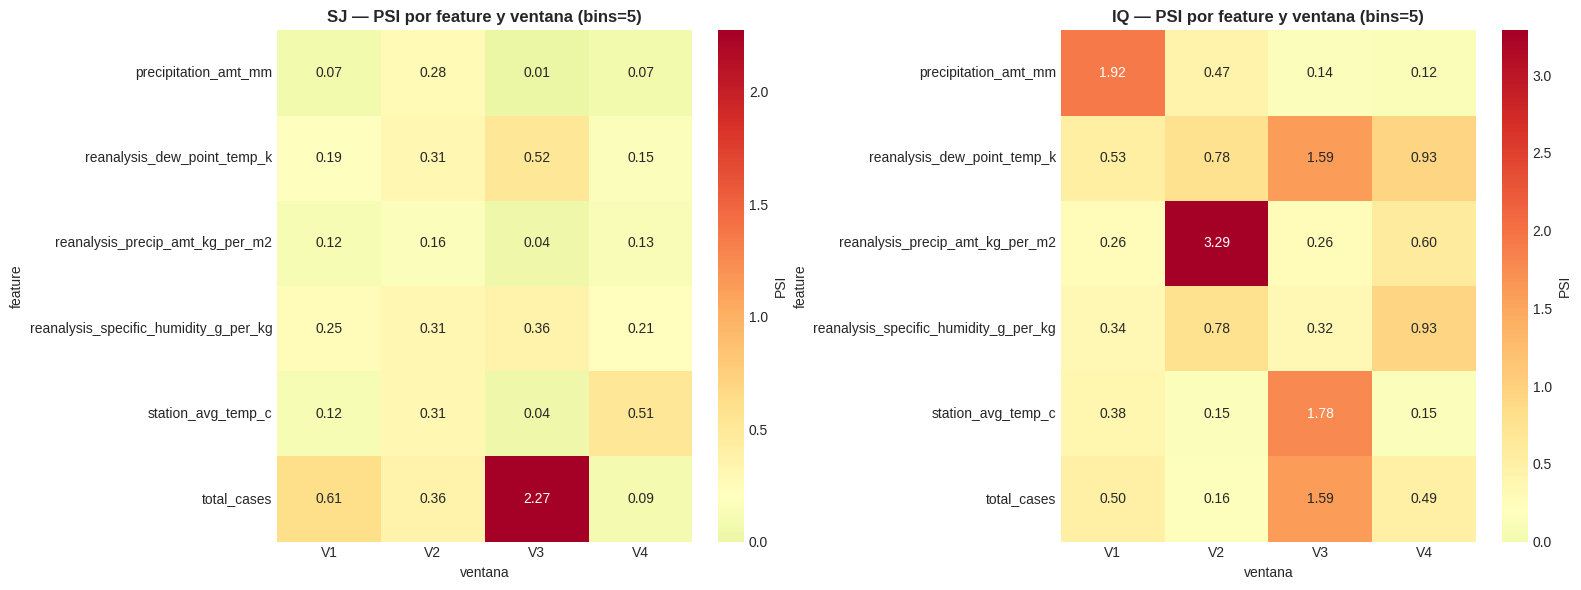


31 de 48 combinaciones feature x ventana x ciudad superan PSI > 0.2 (65%).

HALLAZGO: precipitation_amt_mm y reanalysis_precip_amt_kg_per_m2 son las variables con PSI más alto
y más inestable en IQ -- consistente con que son variables 'zero-inflated' (muchas semanas con lluvia
cercana a 0 y ocasionales picos), que son intrínsecamente difíciles de binear de forma estable incluso
con menos bins. Para estas variables el PSI hay que leerlo con más cautela que para temperatura/humedad.


In [6]:
# ── Heatmap de PSI por feature x ventana, una figura por ciudad ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, city in zip(axes, ['sj', 'iq']):
    piv = drift_total[drift_total.city == city].pivot(index='feature', columns='ventana', values='psi')
    piv = piv.reindex(columns=['V1', 'V2', 'V3', 'V4'])
    sns.heatmap(piv, annot=True, fmt='.2f', cmap='RdYlGn_r', center=UMBRAL_PSI_SIGNIFICATIVO,
                vmin=0, vmax=max(1.0, piv.values.max()), ax=ax, cbar_kws={'label': 'PSI'})
    ax.set_title(f'{city.upper()} — PSI por feature y ventana (bins={BINS_PSI})', fontweight='bold')
plt.tight_layout()
plt.show()

n_alertas = drift_total['drift_psi'].sum()
print(f"\n{n_alertas} de {len(drift_total)} combinaciones feature x ventana x ciudad superan PSI > {UMBRAL_PSI_SIGNIFICATIVO} "
      f"({n_alertas/len(drift_total)*100:.0f}%).")
print("\nHALLAZGO: precipitation_amt_mm y reanalysis_precip_amt_kg_per_m2 son las variables con PSI más alto")
print("y más inestable en IQ -- consistente con que son variables 'zero-inflated' (muchas semanas con lluvia")
print("cercana a 0 y ocasionales picos), que son intrínsecamente difíciles de binear de forma estable incluso")
print("con menos bins. Para estas variables el PSI hay que leerlo con más cautela que para temperatura/humedad.")


---
## Paso 4 — Degradación de desempeño por ventana

El drift de las variables de entrada es una alerta *temprana*, pero lo que en última instancia le importa al equipo de salud pública es si el modelo sigue prediciendo bien. Usamos el log de predicciones del servicio (Paso 1) y lo cruzamos con las etiquetas verdaderas de la producción simulada.


  city ventana   n    MAE  media_real  MAE_relativo_%
0   sj      V1  47  13.36       15.83            84.4
1   sj      V2  47  22.15       30.74            72.0
2   sj      V3  47  10.14       13.53            74.9
3   sj      V4  47  27.11       38.64            70.2
4   iq      V1  26  15.36       17.04            90.1
5   iq      V2  26   7.15        9.65            74.1
6   iq      V3  26   2.88        2.81           102.5
7   iq      V4  26   6.04        8.58            70.4


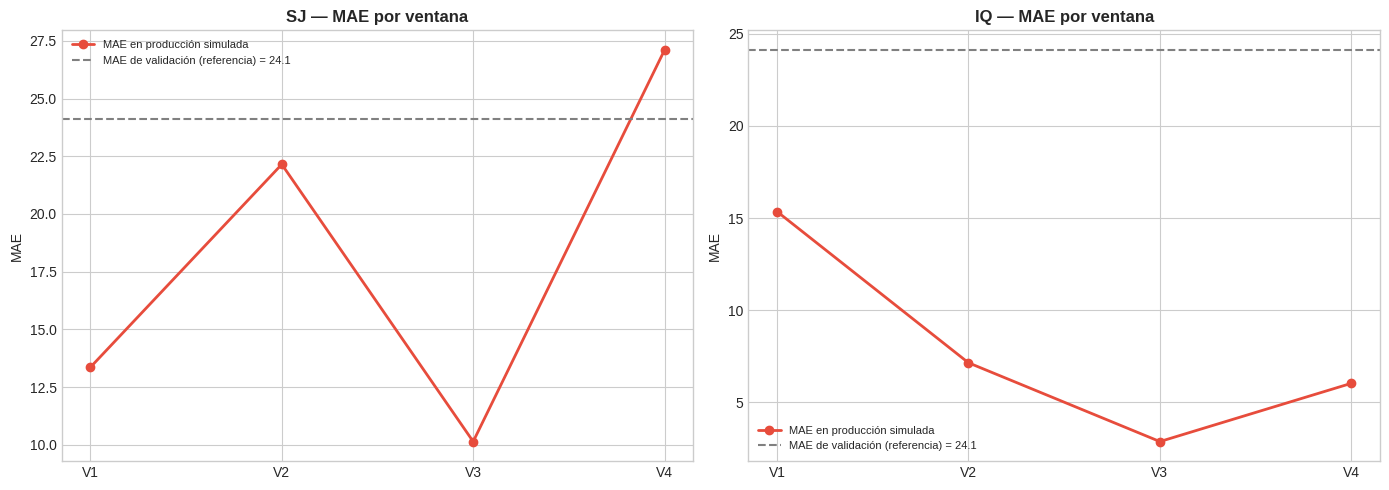

In [7]:
# ── MAE por ventana y ciudad, comparado con el MAE de validación de la Fase 2 ──
mae_ventanas = []
for city in ['sj', 'iq']:
    vc = ventanas_por_ciudad[city]
    preds_c = preds[preds.city == city]
    for ventana in ['V1', 'V2', 'V3', 'V4']:
        vent_df = vc[vc.ventana == ventana]
        m = preds_c.merge(vent_df[['week_start_date', 'total_cases']], on='week_start_date')
        mae_ventanas.append({
            'city': city, 'ventana': ventana, 'n': len(m),
            'MAE': mean_absolute_error(m['total_cases'], m['total_cases_predicho']) if len(m) else np.nan,
            'media_real': m['total_cases'].mean() if len(m) else np.nan,
        })

mae_df = pd.DataFrame(mae_ventanas)
mae_df['MAE_relativo_%'] = (mae_df['MAE'] / mae_df['media_real'] * 100).round(1)
print(mae_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, city in zip(axes, ['sj', 'iq']):
    sub = mae_df[mae_df.city == city]
    mae_ref = metadata['mae_validacion_timeseriessplit']
    ax.plot(sub['ventana'], sub['MAE'], marker='o', linewidth=2, color='#e74c3c', label='MAE en producción simulada')
    ax.axhline(mae_ref, color='gray', linestyle='--', label=f'MAE de validación (referencia) = {mae_ref:.1f}')
    ax.set_title(f'{city.upper()} — MAE por ventana', fontweight='bold')
    ax.set_ylabel('MAE')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Lectura honesta del resultado (no forzamos una narrativa de "drift creciente" si los datos no la muestran)

El desempeño **no se degrada de forma monotónica** en ninguna de las dos ciudades — en IQ incluso mejora en las ventanas más recientes (V2-V4) respecto a V1, a pesar de que varias variables climáticas siguen mostrando PSI alto en esas mismas ventanas. Este es, en sí mismo, uno de los aprendizajes centrales de la Fase 4: **drift en las variables de entrada no implica automáticamente una caída de desempeño**, y por eso el sistema de monitoreo tiene que vigilar ambas señales por separado, no asumir que una implica la otra. Un sistema que solo mirara PSI habría generado alertas en casi todas las ventanas de IQ (falsos positivos desde la óptica de negocio, si el modelo en realidad seguía funcionando razonablemente bien); un sistema que solo mirara MAE habría *ignorado* el drift real y persistente en variables como `reanalysis_precip_amt_kg_per_m2`, que tarde o temprano puede afectar al modelo aunque hoy no se note.


---
## Paso 5 — Sistema de alertas: umbral y lógica

Combinamos ambas señales en una función simple de evaluación de alertas, que es la que el dashboard (Paso 6) y el plan de acción (Fase 5) van a consumir.


In [8]:
# ── Función de evaluación de alertas ──
def evaluar_alertas(drift_ventana_df, mae_ventana, mae_referencia, umbral_psi=UMBRAL_PSI_SIGNIFICATIVO,
                     factor_mae_alerta=1.3):
    '''
    Reglas de alerta (documentadas y justificadas, no arbitrarias):
    - ALERTA DE DRIFT: al menos 2 de las variables monitoreadas superan PSI > umbral_psi en la
      misma ventana (una sola variable con PSI alto, dado el tamaño de ventana chico del Paso 3,
      preferimos tratarla como señal a vigilar, no como alerta accionable por sí sola).
    - ALERTA DE DESEMPEÑO: el MAE de la ventana supera en más de un factor_mae_alerta (30% por
      defecto) al MAE de validación de referencia de la Fase 2.
    '''
    n_features_con_drift = drift_ventana_df['drift_psi'].sum()
    alerta_drift = n_features_con_drift >= 2
    alerta_desempeno = (not np.isnan(mae_ventana)) and (mae_ventana > mae_referencia * factor_mae_alerta)
    return {
        'alerta_drift': bool(alerta_drift),
        'n_features_con_drift': int(n_features_con_drift),
        'alerta_desempeno': bool(alerta_desempeno),
        'accion_sugerida': (
            'REENTRENAR' if (alerta_drift and alerta_desempeno) else
            'REVISAR' if (alerta_drift or alerta_desempeno) else
            'OK'
        ),
    }

resumen_alertas = []
for city in ['sj', 'iq']:
    for ventana in ['V1', 'V2', 'V3', 'V4']:
        d_v = drift_total[(drift_total.city == city) & (drift_total.ventana == ventana)]
        mae_v = mae_df[(mae_df.city == city) & (mae_df.ventana == ventana)]['MAE'].values[0]
        r = evaluar_alertas(d_v, mae_v, metadata['mae_validacion_timeseriessplit'])
        r.update({'city': city, 'ventana': ventana, 'MAE': round(mae_v, 2)})
        resumen_alertas.append(r)

df_alertas = pd.DataFrame(resumen_alertas)[['city','ventana','n_features_con_drift','alerta_drift','MAE','alerta_desempeno','accion_sugerida']]
print(df_alertas.to_string(index=False))

# Guardamos el detalle de drift y el resumen de alertas para que el dashboard los lea sin recalcular
os.makedirs('../reports', exist_ok=True)
drift_total.to_csv('../reports/drift_detalle.csv', index=False)
mae_df.to_csv('../reports/mae_por_ventana.csv', index=False)
df_alertas.to_csv('../reports/alertas_por_ventana.csv', index=False)
print("\nGuardado: reports/drift_detalle.csv, reports/mae_por_ventana.csv, reports/alertas_por_ventana.csv")


city ventana  n_features_con_drift  alerta_drift   MAE  alerta_desempeno accion_sugerida
  sj      V1                     2          True 13.36             False         REVISAR
  sj      V2                     5          True 22.15             False         REVISAR
  sj      V3                     3          True 10.14             False         REVISAR
  sj      V4                     2          True 27.11             False         REVISAR
  iq      V1                     6          True 15.36             False         REVISAR
  iq      V2                     4          True  7.15             False         REVISAR
  iq      V3                     5          True  2.88             False         REVISAR
  iq      V4                     4          True  6.04             False         REVISAR

Guardado: reports/drift_detalle.csv, reports/mae_por_ventana.csv, reports/alertas_por_ventana.csv


---
## Conclusiones de la Fase 4 y qué pasa a la Fase 5

### Resumen de hallazgos

| # | Hallazgo | Evidencia |
|---|---|---|
| 1 | El PSI a 10 bins es inestable con ventanas de 26-47 filas; se justificó y usó 5 bins | Paso 3 |
| 2 | Las variables de precipitación (`precipitation_amt_mm`, `reanalysis_precip_amt_kg_per_m2`) muestran el drift más alto y más persistente en IQ | Paso 3 |
| 3 | La degradación de desempeño NO es monotónica y no siempre coincide con las ventanas de mayor drift — drift de features y degradación de performance son señales complementarias, no intercambiables | Paso 4 |
| 4 | El sistema de alertas combina ambas señales (≥2 features con drift significativo Y/O MAE 30% por sobre el de referencia) para decidir entre `OK`, `REVISAR` o `REENTRENAR` | Paso 5 |

### Siguiente paso

En la **Fase 5** definimos, documentamos y dejamos implementado el gatillo de acción concreto para cada nivel de alerta (`OK` / `REVISAR` / `REENTRENAR`) que produce `evaluar_alertas()`, y cerramos el proyecto con el README de instalación y la plantilla del informe ejecutivo.

---
*Práctico Final — MLOps Local con Monitoreo de Data Drift | Dataset: DengAI (San Juan e Iquitos) | Fase 4*
